<a href="https://colab.research.google.com/github/harunsy/LogisticRegression.ipynb/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tugas Praktik: Klasifikasi dengan Logistic Regression
## anggota kelompok: Harunsyah (24523225)

### Tujuan
Mahasiswa melakukan praktik klasifikasi menggunakan algoritma Logistic Regression untuk menyelesaikan suatu permasalahan klasifikasi pada dataset pilihan.

### Ketentuan
1. Tugas dikerjakan berkelompok (maksimal 3 mahasiswa per kelompok).
2. Gunakan dataset bebas yang sesuai untuk kasus klasifikasi (misalnya dari Kaggle, UCI, Hugging Face, atau sumber lain).
3. Lakukan proses dasar klasifikasi:
    * Memahami dataset dan target klasifikasi
    * Preprocessing data yang diperlukan
    * Pembagian data training dan testing
    * Membangun model Logistic Regression
4. Tampilkan hasil evaluasi model menggunakan:
    * Classification Report (precision, recall, f1-score, support)
    * Confusion Matrix beserta visualisasinya (beri label sumbu yang jelas)
5. Tampilkan beberapa contoh hasil prediksi (y_pred) dan bandingkan dengan label sebenarnya (y_test).

### Analisis yang Diminta
Jelaskan secara singkat:
1. Bagaimana kinerja model berdasarkan classification report?
2. Apa makna True Positive, False Positive, True Negative, dan False Negative pada studi kasus yang Anda pilih?
3. Berikan kesimpulan mengenai seberapa baik Logistic Regression bekerja pada dataset yang digunakan.

### Luaran yang Dikumpulkan
* Notebook Python/Google Colab (.ipynb) berisi kode dan analisis.
* Unggah seluruh kode dan hasil pekerjaan ke GitHub kelompok.
* Setiap mahasiswa wajib submit link GitHub di Google Classroom sebagai bukti kehadiran.

### Langkah 1: Memuat dan Memahami Dataset

Untuk memulai, silakan pilih dataset yang ingin Anda gunakan. Anda bisa mengunggahnya ke sesi Colab atau memberikan tautan langsung (misalnya dari Kaggle atau UCI). Setelah itu, kita akan memuatnya ke dalam Pandas DataFrame dan memahami strukturnya.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- Silakan tentukan jalur dataset Anda di sini ---
# Contoh:
# dataset_path = 'nama_file_anda.csv'
# df = pd.read_csv(dataset_path)

# Atau jika menggunakan dataset populer, misalnya Iris (untuk demonstrasi):
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                  columns=iris['feature_names'] + ['target'])


print("5 baris pertama dataset:")
display(df.head())

print("Informasi dataset:")
df.info()

print("Deskripsi statistik:")
display(df.describe())

5 baris pertama dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    float64
dtypes: float64(5)
memory usage: 6.0 KB
Deskripsi statistik:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Langkah 2: Pra-pemrosesan Data dan Pembagian Dataset

Pada langkah ini, kita akan mempersiapkan data untuk pelatihan model. Ini meliputi pemisahan fitur dan target, penskalaan fitur, dan pembagian dataset menjadi set pelatihan dan pengujian.

In [25]:
# Memisahkan fitur (X) dan target (y)
X = df.drop('target', axis=1) # Fitur adalah semua kolom kecuali 'target'
y = df['target'] # Target adalah kolom 'target'

print("Bentuk X (fitur):", X.shape)
print("Bentuk y (target):", y.shape)

Bentuk X (fitur): (150, 4)
Bentuk y (target): (150,)


In [26]:
# Penskalaan Fitur
# StandardScaler akan mengubah data sehingga memiliki rata-rata 0 dan standar deviasi 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Mengubah kembali ke DataFrame untuk kemudahan inspeksi (opsional)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("5 baris pertama X setelah penskalaan:")
display(X_scaled_df.head())

5 baris pertama X setelah penskalaan:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [27]:
# Pembagian Data Training dan Testing
# Kita akan membagi data menjadi 80% untuk training dan 20% untuk testing.
# random_state digunakan agar hasil pembagian konsisten setiap kali kode dijalankan.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)")
print(f"Jumlah data testing: {len(X_test)} ({len(X_test)/len(df)*100:.0f}%)")

Jumlah data training: 120 (80%)
Jumlah data testing: 30 (20%)


### Langkah 3: Membangun Model Logistic Regression

Sekarang kita akan membangun model klasifikasi menggunakan Logistic Regression. Model ini akan dilatih menggunakan data training dan kemudian digunakan untuk membuat prediksi pada data testing.

In [28]:
# Inisialisasi Model Logistic Regression
model = LogisticRegression(random_state=42, solver='liblinear') # Gunakan solver liblinear untuk dataset kecil dan multilabel (seperti Iris)

# Melatih model (fitting) pada data training
model.fit(X_train, y_train)

print("Model Logistic Regression telah berhasil dilatih.")

# Membuat prediksi pada data testing
y_pred = model.predict(X_test)

print("Prediksi pada data testing telah dibuat.")
print("Beberapa contoh prediksi (y_pred) dibandingkan dengan label sebenarnya (y_test):")
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(comparison_df.head())

Model Logistic Regression telah berhasil dilatih.
Prediksi pada data testing telah dibuat.
Beberapa contoh prediksi (y_pred) dibandingkan dengan label sebenarnya (y_test):


,Actual,Predicted
73,1.0,1.0
18,0.0,0.0
118,2.0,2.0
78,1.0,1.0
76,1.0,1.0


### Langkah 4: Evaluasi Model

Pada langkah ini, kita akan mengevaluasi kinerja model Logistic Regression menggunakan beberapa metrik penting, yaitu Classification Report (precision, recall, f1-score, support) dan Confusion Matrix.

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        10
         1.0       1.00      0.89      0.94         9
         2.0       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



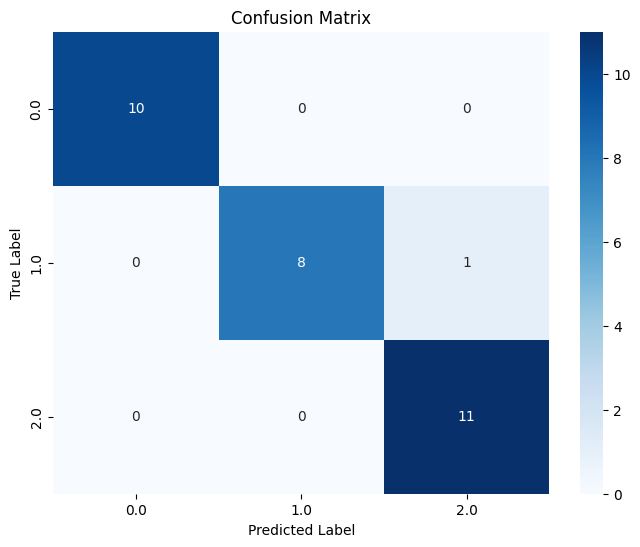

Accuracy Score: 0.9666666666666667


In [29]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Menghitung Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Accuracy Score:", accuracy_score(y_test, y_pred))

### Langkah 3: Membangun Model Logistic Regression

Sekarang kita akan membangun model klasifikasi menggunakan Logistic Regression. Model ini akan dilatih menggunakan data training dan kemudian digunakan untuk membuat prediksi pada data testing.

In [30]:
# Inisialisasi Model Logistic Regression
model = LogisticRegression(random_state=42, solver='liblinear') # Gunakan solver liblinear untuk dataset kecil dan multilabel (seperti Iris)

# Melatih model (fitting) pada data training
model.fit(X_train, y_train)

print("Model Logistic Regression telah berhasil dilatih.")

# Membuat prediksi pada data testing
y_pred = model.predict(X_test)

print("Prediksi pada data testing telah dibuat.")
print("Beberapa contoh prediksi (y_pred) dibandingkan dengan label sebenarnya (y_test):")
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(comparison_df.head())

Model Logistic Regression telah berhasil dilatih.
Prediksi pada data testing telah dibuat.
Beberapa contoh prediksi (y_pred) dibandingkan dengan label sebenarnya (y_test):


,Actual,Predicted
73,1.0,1.0
18,0.0,0.0
118,2.0,2.0
78,1.0,1.0
76,1.0,1.0
